In [3]:


# Базовые библиотеки для воспроизводимости, анализа и удобного отображения результатов.
import random
from typing import Iterable

import numpy as np
import pandas as pd
import torch

from transformers import AutoModel, AutoTokenizer



In [4]:


# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Берём стандартную мультиязычную BERT-модель: она хорошо подходит для русскоязычных примеров.
MODEL_NAME = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded:", MODEL_NAME)
print("Tokenizer class:", tokenizer.__class__.__name__)
print("Model max length:", tokenizer.model_max_length)



Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: bert-base-multilingual-cased
Tokenizer class: BertTokenizer
Model max length: 512


## Токенизация


In [6]:
sample_texts = [
    "За окном идёт дождь, но алгоритм продолжает обучение без ошибок.",
    "GPT обрабатывает последовательности, а не отдельные слова в изоляции.",
    "Модели машинного обучения требуют много памяти, но их результаты того стоят.",
    "Телефон +7 (123) 456-78-90 и домен my-site.ru/train?epochs=10 будут корректно токенизированы.",
    "СуперПуперМегаОченьДлинныйСоставнойТерминБезРазделителей разбивается токенизатором на субслова.",
]
text_pairs = [
    ("На тестовой выборке модель достигла ROC-AUC 0.94.", "Однако на новых данных метрика упала до 0.87."),
    ("Разработчик очистил данные от выбросов.", "После этого он нормализовал признаки и запустил обучение."),
    ("Это начало рассуждения о трансформерах.", "А это его продолжение про механизм внимания."),
]

display(pd.DataFrame({"text": sample_texts}))
display(pd.DataFrame(text_pairs, columns=["text_a", "text_b"]))



,text
0,"За окном идёт дождь, но алгоритм продолжает об..."
1,"GPT обрабатывает последовательности, а не отде..."
2,Модели машинного обучения требуют много памяти...
3,Телефон +7 (123) 456-78-90 и домен my-site.ru/...
4,СуперПуперМегаОченьДлинныйСоставнойТерминБезРа...


,text_a,text_b
0,На тестовой выборке модель достигла ROC-AUC 0.94.,Однако на новых данных метрика упала до 0.87.
1,Разработчик очистил данные от выбросов.,После этого он нормализовал признаки и запусти...
2,Это начало рассуждения о трансформерах.,А это его продолжение про механизм внимания.


In [7]:
# Удобная вспомогательная функция для табличного просмотра токенизации.
def inspect_single_text(text: str, tokenizer) -> pd.DataFrame:
    tokens = tokenizer.tokenize(text)
    token_ids = tokenizer.encode(text, add_special_tokens=False)
    decoded_pieces = [tokenizer.decode([tid]) for tid in token_ids]
    return pd.DataFrame(
        {
            "position": list(range(len(tokens))),
            "token": tokens,
            "token_id": token_ids,
            "decoded_piece": decoded_pieces,
        }
    )

example_text = sample_texts[1]
print("Исходный текст:")
print(example_text)
print()

tokens = tokenizer.tokenize(example_text)
token_ids = tokenizer.encode(example_text, add_special_tokens=False)
decoded_text = tokenizer.decode(token_ids)

print("Токены:")
print(tokens)
print()

print("ID токенов:")
print(token_ids)
print()

print("decode(token_ids):")
print(decoded_text)

display(inspect_single_text(example_text, tokenizer))

Исходный текст:
GPT обрабатывает последовательности, а не отдельные слова в изоляции.

Токены:
['GP', '##T', 'об', '##ра', '##бат', '##ывает', 'после', '##дова', '##тельно', '##сти', ',', 'а', 'не', 'отдельные', 'слова', 'в', 'из', '##оля', '##ции', '.']

ID токенов:
[25236, 11090, 13248, 11079, 74329, 36708, 11921, 38622, 34136, 12189, 117, 541, 10375, 98261, 25217, 543, 10387, 74269, 12559, 119]

decode(token_ids):
GPT обрабатывает последовательности, а не отдельные слова в изоляции.


,position,token,token_id,decoded_piece
0,0,GP,25236,GP
1,1,##T,11090,##T
2,2,об,13248,об
3,3,##ра,11079,##ра
4,4,##бат,74329,##бат
5,5,##ывает,36708,##ывает
6,6,после,11921,после
7,7,##дова,38622,##дова
8,8,##тельно,34136,##тельно
9,9,##сти,12189,##сти


In [8]:
# Смотрим служебные токены токенизатора.
special_tokens_df = pd.DataFrame(
    {
        "name": [
            "cls_token",
            "sep_token",
            "pad_token",
            "unk_token",
            "mask_token",
        ],
        "token": [
            tokenizer.cls_token,
            tokenizer.sep_token,
            tokenizer.pad_token,
            tokenizer.unk_token,
            tokenizer.mask_token,
        ],
        "token_id": [
            tokenizer.cls_token_id,
            tokenizer.sep_token_id,
            tokenizer.pad_token_id,
            tokenizer.unk_token_id,
            tokenizer.mask_token_id,
        ],
    }
)

display(special_tokens_df)

# Смотрим полную последовательность с добавлением special tokens.
# Также запрашиваем token_type_ids, чтобы увидеть их для одиночного текста
# (они все равны 0 – контраст с парой текстов покажем в следующей секции).
encoded_with_specials = tokenizer(
    example_text,
    add_special_tokens=True,
    return_attention_mask=True,
    return_token_type_ids=True,
)

full_ids = encoded_with_specials["input_ids"]
full_tokens = tokenizer.convert_ids_to_tokens(full_ids)

display(
    pd.DataFrame(
        {
            "position": list(range(len(full_ids))),
            "token": full_tokens,
            "token_id": full_ids,
            "attention_mask": encoded_with_specials["attention_mask"],
            "token_type_id": encoded_with_specials["token_type_ids"],
        }
    )
)

print("Все token_type_ids для одного текста равны 0.")
print("Как они меняются для пары текстов – смотрим в секции 6.")

,name,token,token_id
0,cls_token,[CLS],101
1,sep_token,[SEP],102
2,pad_token,[PAD],0
3,unk_token,[UNK],100
4,mask_token,[MASK],103


,position,token,token_id,attention_mask,token_type_id
0,0,[CLS],101,1,0
1,1,GP,25236,1,0
2,2,##T,11090,1,0
3,3,об,13248,1,0
4,4,##ра,11079,1,0
5,5,##бат,74329,1,0
6,6,##ывает,36708,1,0
7,7,после,11921,1,0
8,8,##дова,38622,1,0
9,9,##тельно,34136,1,0


Все token_type_ids для одного текста равны 0.
Как они меняются для пары текстов – смотрим в секции 6.


In [9]:
pair_a, pair_b = text_pairs[0]

pair_encoding = tokenizer(
    pair_a,
    pair_b,
    return_attention_mask=True,
    return_token_type_ids=True,
)

pair_ids = pair_encoding["input_ids"]
pair_tokens = tokenizer.convert_ids_to_tokens(pair_ids)
pair_mask = pair_encoding["attention_mask"]
pair_types = pair_encoding["token_type_ids"]

display(
    pd.DataFrame(
        {
            "position": list(range(len(pair_ids))),
            "token": pair_tokens,
            "token_id": pair_ids,
            "attention_mask": pair_mask,
            "token_type_id": pair_types,
        }
    )
)

print("Текст A:")
print(pair_a)
print()
print("Текст B:")
print(pair_b)

,position,token,token_id,attention_mask,token_type_id
0,0,[CLS],101,1,0
1,1,На,10778,1,0
2,2,те,13613,1,0
3,3,##стов,41505,1,0
4,4,##ой,11292,1,0
5,5,вы,96195,1,0
6,6,##бор,20545,1,0
7,7,##ке,11557,1,0
8,8,модель,41344,1,0
9,9,до,10344,1,0


Текст A:
На тестовой выборке модель достигла ROC-AUC 0.94.

Текст B:
Однако на новых данных метрика упала до 0.87.


In [10]:
batch = tokenizer(
    sample_texts,
    padding=True,
    truncation=True,
    max_length=24,
    return_tensors="pt",
)

print("Ключи batch:")
print(batch.keys())
print()

for key, value in batch.items():
    print(f"{key}: shape={tuple(value.shape)}")

# Для наглядности покажем длины последовательностей до и после padding/truncation.
raw_lengths = [len(tokenizer.encode(text, add_special_tokens=True)) for text in sample_texts]
real_token_count = batch["attention_mask"].sum(dim=1).tolist()

display(
    pd.DataFrame(
        {
            "text": sample_texts,
            "raw_length_with_specials": raw_lengths,
            "real_token_count": real_token_count,
        }
    )
)

Ключи batch:
KeysView({'input_ids': tensor([[   101,  11712,  40936,  12391,  88544,  10344,  12025,  41237,    117,
          11279,  21720, 104668,  12709,  17961,  50856,  25471,  61703,  13012,
            555,  13523,  62078,    119,    102,      0],
        [   101,  25236,  11090,  13248,  11079,  74329,  36708,  11921,  38622,
          34136,  12189,    117,    541,  10375,  98261,  25217,    543,  10387,
          74269,  12559,    119,    102,      0,      0],
        [   101,    521,  82562,  10783,  51290,  11050,  60992,    559,  14348,
          19590,  13714,  16318,  50447,    117,  11279,  12064,  75455,  12409,
         108804,  13081,    119,    102,      0,      0],
        [   101, 105542,    116,    128,    113,  16968,    114,  36380,    118,
          12492,    118,  10919,    549,  44838,  10267,  15127,    118,  11920,
            119,  13483,    120,  17767,    136,    102],
        [   101,  19193,  29633,  16027, 108741,  10519,  21345,  48372,  18002,
   

,text,raw_length_with_specials,real_token_count
0,"За окном идёт дождь, но алгоритм продолжает об...",23,23
1,"GPT обрабатывает последовательности, а не отде...",22,22
2,Модели машинного обучения требуют много памяти...,22,22
3,Телефон +7 (123) 456-78-90 и домен my-site.ru/...,38,24
4,СуперПуперМегаОченьДлинныйСоставнойТерминБезРа...,39,24


In [11]:
!pip install datasets

In [12]:
from datasets import load_dataset

# Загружаем датасет emotion (рекомендуемый вариант из ДЗ)
dataset = load_dataset("dair-ai/emotion")

# Или альтернативный вариант с тем же датасетом
# dataset = load_dataset("jeffnyman/emotions") [citation:2][citation:6]

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [13]:
print(dataset["train"][0])
# {'text': 'i didnt feel humiliated', 'label': 0}

# Посмотрим несколько примеров
for i in range(5):
    print(f"Текст: {dataset['train'][i]['text']}")
    print(f"Метка: {dataset['train'][i]['label']}\n")

{'text': 'i didnt feel humiliated', 'label': 0}
Текст: i didnt feel humiliated
Метка: 0

Текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Метка: 0

Текст: im grabbing a minute to post i feel greedy wrong
Метка: 3

Текст: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Метка: 2

Текст: i am feeling grouchy
Метка: 3



In [14]:
from transformers import AutoTokenizer
import pandas as pd

MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


sample_texts_for_tokenization = [
    dataset["train"][0]["text"],
    dataset["train"][5]["text"],
    dataset["train"][10]["text"]
]



config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [15]:
text_example = sample_texts_for_tokenization[0]
print(f"Исходный текст: '{text_example}'")
print(f"Длина текста: {len(text_example.split())} слов\n")

Исходный текст: 'i didnt feel humiliated'
Длина текста: 4 слов



In [16]:
tokens = tokenizer.tokenize(text_example)
print(f"Токены: {tokens}")
print(f"Количество токенов: {len(tokens)}")

Токены: ['i', 'didn', '##t', 'feel', 'humiliated']
Количество токенов: 5


In [17]:
input_ids = tokenizer.encode(text_example)
print(f"input_ids: {input_ids}")
print(f"Длина input_ids: {len(input_ids)}")

input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102]
Длина input_ids: 7


In [19]:
encoded = tokenizer(text_example, add_special_tokens=True)
print(f"Текст: '{text_example}'")
print(f"Токены с special tokens: {tokenizer.convert_ids_to_tokens(encoded['input_ids'])}")
print(f"input_ids: {encoded['input_ids']}")
print(f"attention_mask: {encoded['attention_mask']}")

Текст: 'i didnt feel humiliated'
Токены с special tokens: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]']
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1]


In [22]:
results = []
for idx, text in enumerate(sample_texts_for_tokenization[:3]):  # берем 3 примера из датасета
    # Токенизируем с возвратом tensors
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        return_tensors="pt",  # возвращаем PyTorch тензоры
        padding=False,
        truncation=False
    )

    tokens_list = tokenizer.tokenize(text)
    results.append({
        "sample_idx": idx,
        "original_text": text[:50] + "..." if len(text) > 50 else text,
        "num_tokens": len(tokens_list),
        "tokens": tokens_list[:10],  # показываем первые 10 токенов
        "input_ids_shape": encoding["input_ids"].shape,
        "attention_mask": encoding["attention_mask"][0].tolist()
    })

    print(f"\nПример {idx}:")
    print(f"  Текст: {text}")
    print(f"  Количество токенов: {len(tokens_list)}")
    print(f"  Токены (первые 10): {tokens_list[:10]}")
    print(f"  input_ids: {encoding['input_ids'][0].tolist()}")
    print(f"  attention_mask: {encoding['attention_mask'][0].tolist()}")


Пример 0:
  Текст: i didnt feel humiliated
  Количество токенов: 5
  Токены (первые 10): ['i', 'didn', '##t', 'feel', 'humiliated']
  input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102]
  attention_mask: [1, 1, 1, 1, 1, 1, 1]

Пример 1:
  Текст: ive been feeling a little burdened lately wasnt sure why that was
  Количество токенов: 15
  Токены (первые 10): ['iv', '##e', 'been', 'feeling', 'a', 'little', 'burden', '##ed', 'lately', 'wasn']
  input_ids: [101, 4921, 2063, 2042, 3110, 1037, 2210, 10859, 2098, 9906, 2347, 2102, 2469, 2339, 2008, 2001, 102]
  attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Пример 2:
  Текст: i feel like i have to make the suffering i m seeing mean something
  Количество токенов: 14
  Токены (первые 10): ['i', 'feel', 'like', 'i', 'have', 'to', 'make', 'the', 'suffering', 'i']
  input_ids: [101, 1045, 2514, 2066, 1045, 2031, 2000, 2191, 1996, 6114, 1045, 1049, 3773, 2812, 2242, 102]
  attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [23]:
texts_diff_length = [
    "Short text",
    "This is a medium length text with several words",
    "This is a very long text that contains many many many many many many words to demonstrate how padding works in practice"
]

print("Тексты разной длины:")
for i, t in enumerate(texts_diff_length):
    print(f"  {i+1}. '{t}' ({len(t.split())} слов)")

# Токенизируем с padding
encoded_padded = tokenizer(
    texts_diff_length,
    padding=True,  # добавляем паддинг до максимальной длины в батче
    truncation=False,
    return_tensors="pt"
)

print("\nРезультат с padding=True:")
print(f"  Форма input_ids: {encoded_padded['input_ids'].shape}")
print(f"  Форма attention_mask: {encoded_padded['attention_mask'].shape}")
print(f"\n  input_ids для каждого текста:")
for i, ids in enumerate(encoded_padded['input_ids']):
    print(f"    Текст {i+1}: {ids.tolist()}")
    print(f"    attention_mask: {encoded_padded['attention_mask'][i].tolist()}")
    # Показываем, где добавлены padding токены
    pad_positions = (ids == tokenizer.pad_token_id).nonzero(as_tuple=True)[0]
    if len(pad_positions) > 0:
        print(f"    Padding добавлен на позициях: {pad_positions.tolist()}")

Тексты разной длины:
  1. 'Short text' (2 слов)
  2. 'This is a medium length text with several words' (9 слов)
  3. 'This is a very long text that contains many many many many many many words to demonstrate how padding works in practice' (22 слов)

Результат с padding=True:
  Форма input_ids: torch.Size([3, 25])
  Форма attention_mask: torch.Size([3, 25])

  input_ids для каждого текста:
    Текст 1: [101, 2460, 3793, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    attention_mask: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    Padding добавлен на позициях: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
    Текст 2: [101, 2023, 2003, 1037, 5396, 3091, 3793, 2007, 2195, 2616, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    Padding добавлен на позициях: [11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 2

## Инференс модели


In [24]:
# Импортируем необходимые библиотеки
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
import numpy as np
from torch.nn.functional import softmax


INFERENCE_MODEL_NAME = "bhadresh-savani/bert-base-uncased-emotion"


print(f"\n1. ЗАГРУЗКА МОДЕЛИ: {INFERENCE_MODEL_NAME}")


1. ЗАГРУЗКА МОДЕЛИ: bhadresh-savani/bert-base-uncased-emotion


In [25]:
inference_tokenizer = AutoTokenizer.from_pretrained(INFERENCE_MODEL_NAME)
inference_model = AutoModelForSequenceClassification.from_pretrained(INFERENCE_MODEL_NAME)
inference_model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
inference_model.to(device)
print(f"Модель загружена на устройство: {device}")


config.json:   0%|          | 0.00/935 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bhadresh-savani/bert-base-uncased-emotion
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Модель загружена на устройство: cuda


In [26]:
# 2. Подготавливаем тестовые тексты (из датасета + свои примеры)

test_texts = [
    # Из датасета emotion
    dataset["validation"][0]["text"],
    dataset["validation"][1]["text"],
    dataset["validation"][2]["text"],
    dataset["validation"][3]["text"],
    dataset["validation"][4]["text"]
]


emotion_labels = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

print(f"Всего тестовых примеров: {len(test_texts)}")
print(f"Классы эмоций: {emotion_labels}")

Всего тестовых примеров: 5
Классы эмоций: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [27]:
# 3. Функция для инференса
def predict_emotion(texts, model, tokenizer, device):

    model.eval()
    predictions = []
    probabilities = []

    with torch.no_grad():  # отключаем градиенты для инференса
        for text in texts:
            # Токенизируем текст
            inputs = tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                max_length=128,
                padding=True
            )

            # Перемещаем на устройство
            inputs = {k: v.to(device) for k, v in inputs.items()}

            # Получаем предсказания модели
            outputs = model(**inputs)
            logits = outputs.logits

            # Получаем вероятности через softmax
            probs = softmax(logits, dim=1)

            # Предсказанный класс (с наибольшей вероятностью)
            pred_class = torch.argmax(probs, dim=1).item()

            # Сохраняем результаты
            predictions.append(pred_class)
            probabilities.append(probs.cpu().numpy()[0])

    return predictions, probabilities


In [28]:
# 4. Запускаем инференс


predictions, probabilities = predict_emotion(
    test_texts,
    inference_model,
    inference_tokenizer,
    device
)

In [29]:
results_table = []
for i, (text, pred, probs) in enumerate(zip(test_texts, predictions, probabilities)):
    predicted_emotion = emotion_labels[pred]
    confidence = np.max(probs) * 100

    # Для текстов из датасета показываем true label
    if i < 5:  # первые 5 - из датасета
        true_label_idx = dataset["validation"][i]["label"]
        true_emotion = emotion_labels[true_label_idx]
        is_correct = (pred == true_label_idx)

        results_table.append({
            "example": i+1,
            "text": text[:60] + "..." if len(text) > 60 else text,
            "true_emotion": true_emotion,
            "predicted_emotion": predicted_emotion,
            "confidence": f"{confidence:.1f}%",
            "correct": "✓" if is_correct else "✗"
        })

        print(f"\nПример {i+1} (из датасета):")
        print(f"  Текст: {text}")
        print(f"  True emotion: {true_emotion}")
        print(f"  Предсказано: {predicted_emotion}")
        print(f"  Уверенность: {confidence:.1f}%")
        print(f"  Верно: {'ДА' if is_correct else 'НЕТ'}")

    else:  # свои примеры
        results_table.append({
            "example": i+1,
            "text": text[:60] + "..." if len(text) > 60 else text,
            "true_emotion": "N/A",
            "predicted_emotion": predicted_emotion,
            "confidence": f"{confidence:.1f}%",
            "correct": "N/A"
        })

        print(f"\nПример {i+1} (свой текст):")
        print(f"  Текст: {text}")
        print(f"  Предсказано: {predicted_emotion}")
        print(f"  Уверенность: {confidence:.1f}%")


Пример 1 (из датасета):
  Текст: im feeling quite sad and sorry for myself but ill snap out of it soon
  True emotion: sadness
  Предсказано: sadness
  Уверенность: 99.9%
  Верно: ДА

Пример 2 (из датасета):
  Текст: i feel like i am still looking at a blank canvas blank pieces of paper
  True emotion: sadness
  Предсказано: sadness
  Уверенность: 99.9%
  Верно: ДА

Пример 3 (из датасета):
  Текст: i feel like a faithful servant
  True emotion: love
  Предсказано: joy
  Уверенность: 84.8%
  Верно: НЕТ

Пример 4 (из датасета):
  Текст: i am just feeling cranky and blue
  True emotion: anger
  Предсказано: anger
  Уверенность: 99.8%
  Верно: ДА

Пример 5 (из датасета):
  Текст: i can have for a treat or if i am feeling festive
  True emotion: joy
  Предсказано: joy
  Уверенность: 99.9%
  Верно: ДА


In [30]:
# 7. Оценка качества на небольшой выборке из validation


# Берем 50 примеров из validation для оценки
sample_size = 50
val_texts = dataset["validation"]["text"][:sample_size]
val_labels = dataset["validation"]["label"][:sample_size]

# Запускаем инференс
val_predictions, _ = predict_emotion(val_texts, inference_model, inference_tokenizer, device)

# Считаем accuracy
correct = sum(1 for pred, true in zip(val_predictions, val_labels) if pred == true)
accuracy = correct / sample_size

print(f"Выборка из {sample_size} примеров validation:")
print(f"  Правильных предсказаний: {correct}/{sample_size}")
print(f"  Accuracy: {accuracy:.2%}")

# Accuracy по каждому классу
from collections import defaultdict
class_correct = defaultdict(int)
class_total = defaultdict(int)

for pred, true in zip(val_predictions, val_labels):
    class_total[true] += 1
    if pred == true:
        class_correct[true] += 1

print("\nТочность по каждому классу:")
for class_idx in sorted(class_total.keys()):
    emotion = emotion_labels[class_idx]
    acc = class_correct[class_idx] / class_total[class_idx]
    print(f"  {emotion:10s}: {acc:.2%} ({class_correct[class_idx]}/{class_total[class_idx]})")

Выборка из 50 примеров validation:
  Правильных предсказаний: 46/50
  Accuracy: 92.00%

Точность по каждому классу:
  sadness   : 96.00% (24/25)
  joy       : 92.31% (12/13)
  love      : 80.00% (4/5)
  anger     : 83.33% (5/6)
  fear      : 100.00% (1/1)


## Fine-tuning

In [32]:
# 1. Импортируем необходимые библиотеки для обучения
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from datasets import DatasetDict
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report
import torch
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding

MODEL_CKPT = "bert-base-uncased"
BATCH_SIZE = 16
MAX_LENGTH = 128
LEARNING_RATE = 2e-5
EPOCHS = 3
SEED = 42

print(f"Модель: {MODEL_CKPT}")
print(f"Размер батча: {BATCH_SIZE}")
print(f"Макс. длина: {MAX_LENGTH}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Эпохи: {EPOCHS}")

Модель: bert-base-uncased
Размер батча: 16
Макс. длина: 128
Learning rate: 2e-05
Эпохи: 3


In [33]:
# 2. Загружаем токенизатор и модель
tokenizer = AutoTokenizer.from_pretrained(MODEL_CKPT)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CKPT,
    num_labels=6,  # 6 классов эмоций
    id2label={0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"},
    label2id={"sadness": 0, "joy": 1, "love": 2, "anger": 3, "fear": 4, "surprise": 5}
)

# Определяем устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Модель загружена на: {device}")
print(f"Количество параметров: {model.num_parameters():,}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Модель загружена на: cuda
Количество параметров: 109,486,854


In [34]:
# 3. Токенизация датасета


def tokenize_function(examples):
    """Функция токенизации для всего датасета"""
    return tokenizer(
        examples["text"],
        truncation=True,
        padding=False,
        max_length=MAX_LENGTH,
        return_tensors=None
    )


print("Токенизация train...")
tokenized_train = dataset["train"].map(tokenize_function, batched=True)
print("Токенизация validation...")
tokenized_val = dataset["validation"].map(tokenize_function, batched=True)
print("Токенизация test...")
tokenized_test = dataset["test"].map(tokenize_function, batched=True)


tokenized_train = tokenized_train.remove_columns(["text"]).rename_column("label", "labels")
tokenized_val = tokenized_val.remove_columns(["text"]).rename_column("label", "labels")
tokenized_test = tokenized_test.remove_columns(["text"]).rename_column("label", "labels")

tokenized_train.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_val.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_test.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print(f"Размер train после токенизации: {len(tokenized_train)}")
print(f"Размер validation: {len(tokenized_val)}")
print(f"Размер test: {len(tokenized_test)}")

Токенизация train...


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Токенизация validation...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Токенизация test...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Размер train после токенизации: 16000
Размер validation: 2000
Размер test: 2000


In [35]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding=True)


In [36]:
def compute_metrics(eval_pred):
    """Функция для вычисления метрик во время обучения"""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    # Вычисляем accuracy и f1 macro
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')

    return {
        'accuracy': accuracy,
        'f1_macro': f1
    }

In [38]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    warmup_ratio=0.1,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    eval_strategy="epoch",  # ← было evaluation_strategy, стало eval_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    push_to_hub=False,
    report_to="none",
    seed=SEED,
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,
)

print("Параметры обучения настроены:")
print(f"  - Эпох: {EPOCHS}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Learning rate: {LEARNING_RATE}")
print(f"  - Сохранение лучшей модели по f1_macro")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Параметры обучения настроены:
  - Эпох: 3
  - Batch size: 16
  - Learning rate: 2e-05
  - Сохранение лучшей модели по f1_macro


In [40]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [41]:
# 8. ЗАПУСК ОБУЧЕНИЯ


try:
    # Обучаем модель
    train_result = trainer.train()



    # Выводим информацию о процессе обучения
    print(f"Общее количество шагов: {train_result.global_step}")
    print(f"Потеря (loss) на последнем шаге: {train_result.training_loss:.4f}")

    # Сохраняем метрики обучения
    train_metrics = train_result.metrics
    print(f"Train runtime: {train_metrics.get('train_runtime', 0):.2f} секунд")
    print(f"Train samples per second: {train_metrics.get('train_samples_per_second', 0):.2f}")

except Exception as e:
    print(f"Ошибка при обучении: {e}")
    print("Попробуйте уменьшить batch_size или max_length при нехватке памяти")


8. ЗАПУСК FINE-TUNING
Начинаем обучение...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.219496,0.200261,0.928500,0.904994
2,0.127420,0.153107,0.934000,0.904683
3,0.086337,0.155143,0.941500,0.918395


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


ОБУЧЕНИЕ ЗАВЕРШЕНО
Общее количество шагов: 3000
Потеря (loss) на последнем шаге: 0.2931
Train runtime: 362.61 секунд
Train samples per second: 132.37


In [42]:
# 9. ОЦЕНКА НА VALIDATION (выбор лучшей модели)

print("9. ОЦЕНКА НА VALIDATION")


# Оцениваем лучшую модель на валидации
val_metrics = trainer.evaluate(tokenized_val)

print("Результаты на validation:")
print(f"  Accuracy: {val_metrics.get('eval_accuracy', 0):.4f}")
print(f"  F1 Macro: {val_metrics.get('eval_f1_macro', 0):.4f}")
print(f"  Loss: {val_metrics.get('eval_loss', 0):.4f}")

9. ОЦЕНКА НА VALIDATION


Результаты на validation:
  Accuracy: 0.9415
  F1 Macro: 0.9184
  Loss: 0.1551


In [43]:
# 10. ФИНАЛЬНАЯ ОЦЕНКА НА TEST (один раз!)

print("10. ФИНАЛЬНАЯ ОЦЕНКА НА TEST")

# Получаем предсказания на test
test_predictions = trainer.predict(tokenized_test)
test_preds = np.argmax(test_predictions.predictions, axis=1)
test_labels = test_predictions.label_ids

# Вычисляем финальные метрики
test_accuracy = accuracy_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds, average='macro')

print(f"\nФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ НА TEST:")
print(f"  Accuracy: {test_accuracy:.4f} ({test_accuracy:.2%})")
print(f"  F1 Macro: {test_f1:.4f}")

# Детальный отчет по классам
print("\nДетальный отчет по каждому классу:")
class_report = classification_report(
    test_labels,
    test_preds,
    target_names=["sadness", "joy", "love", "anger", "fear", "surprise"],
    digits=4
)
print(class_report)

10. ФИНАЛЬНАЯ ОЦЕНКА НА TEST



ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ НА TEST:
  Accuracy: 0.9260 (92.60%)
  F1 Macro: 0.8798

Детальный отчет по каждому классу:
              precision    recall  f1-score   support

     sadness     0.9608    0.9690    0.9649       581
         joy     0.9420    0.9583    0.9501       695
        love     0.8639    0.7987    0.8301       159
       anger     0.9318    0.8945    0.9128       275
        fear     0.8675    0.9062    0.8865       224
    surprise     0.7581    0.7121    0.7344        66

    accuracy                         0.9260      2000
   macro avg     0.8874    0.8732    0.8798      2000
weighted avg     0.9254    0.9260    0.9255      2000



## Exp


In [44]:
experiment_config = {
    "Название эксперимента": "Fine-tuning BERT для классификации эмоций",
    "Датасет": "dair-ai/emotion",
    "Модель": "bert-base-uncased",
    "Количество классов": 6,
    "Классы": ["sadness", "joy", "love", "anger", "fear", "surprise"],
    "Размер train": len(dataset["train"]),
    "Размер validation": len(dataset["validation"]),
    "Размер test": len(dataset["test"]),
    "Макс. длина токенов": MAX_LENGTH,
    "Batch size": BATCH_SIZE,
    "Learning rate": LEARNING_RATE,
    "Количество эпох": EPOCHS,
    "Оптимизатор": "AdamW",
    "Функция потерь": "CrossEntropyLoss",
    "Метрики": "Accuracy, F1 Macro",
    "Ранняя остановка": "patience=2",
    "Device": device.type
}

print("\nКонфигурация эксперимента:")
for key, value in experiment_config.items():
    print(f"  {key}: {value}")


Конфигурация эксперимента:
  Название эксперимента: Fine-tuning BERT для классификации эмоций
  Датасет: dair-ai/emotion
  Модель: bert-base-uncased
  Количество классов: 6
  Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
  Размер train: 16000
  Размер validation: 2000
  Размер test: 2000
  Макс. длина токенов: 128
  Batch size: 16
  Learning rate: 2e-05
  Количество эпох: 3
  Оптимизатор: AdamW
  Функция потерь: CrossEntropyLoss
  Метрики: Accuracy, F1 Macro
  Ранняя остановка: patience=2
  Device: cuda


In [45]:
# 3.2. Результаты эксперимента

# Получаем лучшие метрики из истории обучения
best_val_accuracy = max([log.get('eval_accuracy', 0) for log in trainer.state.log_history if 'eval_accuracy' in log])
best_val_f1 = max([log.get('eval_f1_macro', 0) for log in trainer.state.log_history if 'eval_f1_macro' in log])

print(f"Лучшие результаты на VALIDATION:")
print(f"  Accuracy: {best_val_accuracy:.4f} ({best_val_accuracy:.2%})")
print(f"  F1 Macro: {best_val_f1:.4f}")

print(f"\nФинальные результаты на TEST (однократная оценка):")
print(f"  Accuracy: {test_accuracy:.4f} ({test_accuracy:.2%})")
print(f"  F1 Macro: {test_f1:.4f}")

Лучшие результаты на VALIDATION:
  Accuracy: 0.9415 (94.15%)
  F1 Macro: 0.9184

Финальные результаты на TEST (однократная оценка):
  Accuracy: 0.9260 (92.60%)
  F1 Macro: 0.8798


In [46]:
# Оцениваем готовую модель на той же тестовой выборке
print("Оценка готовой модели на test...")

from transformers import AutoModelForSequenceClassification

baseline_model = AutoModelForSequenceClassification.from_pretrained("bhadresh-savani/bert-base-uncased-emotion")
baseline_model.to(device)
baseline_model.eval()

# Берем подвыборку из test для сравнения (первые 500 примеров для скорости)
sample_size_compare = min(500, len(dataset["test"]))
baseline_texts = dataset["test"]["text"][:sample_size_compare]
baseline_labels = dataset["test"]["label"][:sample_size_compare]

baseline_predictions = []
for text in baseline_texts:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(device)
    with torch.no_grad():
        outputs = baseline_model(**inputs)
        pred = torch.argmax(outputs.logits, dim=1).item()
    baseline_predictions.append(pred)

baseline_accuracy = accuracy_score(baseline_labels, baseline_predictions)
baseline_f1 = f1_score(baseline_labels, baseline_predictions, average='macro')

print(f"\nГотовая модель (bhadresh-savani/bert-base-uncased-emotion):")
print(f"  Accuracy: {baseline_accuracy:.4f} ({baseline_accuracy:.2%})")
print(f"  F1 Macro: {baseline_f1:.4f}")

print(f"\nНаша fine-tuned модель:")
print(f"  Accuracy: {test_accuracy:.4f} ({test_accuracy:.2%})")
print(f"  F1 Macro: {test_f1:.4f}")

# Сравнение
accuracy_improvement = test_accuracy - baseline_accuracy
f1_improvement = test_f1 - baseline_f1

print(f"\nУлучшение после fine-tuning:")
print(f"  Accuracy: +{accuracy_improvement:.4f} ({accuracy_improvement:.2%})")
print(f"  F1 Macro: +{f1_improvement:.4f}")

if accuracy_improvement > 0:
    print("✓ Fine-tuning показал улучшение качества по сравнению с готовой моделью")
else:
    print("! Готовая модель оказалась лучше (возможно, нужна донастройка гиперпараметров)")

Оценка готовой модели на test...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bhadresh-savani/bert-base-uncased-emotion
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Готовая модель (bhadresh-savani/bert-base-uncased-emotion):
  Accuracy: 0.9280 (92.80%)
  F1 Macro: 0.8826

Наша fine-tuned модель:
  Accuracy: 0.9260 (92.60%)
  F1 Macro: 0.8798

Улучшение после fine-tuning:
  Accuracy: +-0.0020 (-0.20%)
  F1 Macro: +-0.0028
! Готовая модель оказалась лучше (возможно, нужна донастройка гиперпараметров)


In [47]:

# Время обучения
train_runtime = train_result.metrics.get('train_runtime', 0)
print(f"Время обучения: {train_runtime:.2f} секунд ({train_runtime/60:.2f} минут)")

# Количество параметров модели
num_params = model.num_parameters()
print(f"Количество параметров модели: {num_params:,}")

# Примерная память (оценка)
if device.type == "cuda":
    memory_allocated = torch.cuda.memory_allocated(device) / 1024**3
    print(f"Использовано GPU памяти: ~{memory_allocated:.2f} GB")
else:
    print("Обучение на CPU")


Время обучения: 362.61 секунд (6.04 минут)
Количество параметров модели: 109,486,854
Использовано GPU памяти: ~2.06 GB


4. АРТЕФАКТЫ

✓ Папка 'artifacts/' создана/проверена

4.1. СОЗДАНИЕ sample_predictions.csv
----------------------------------------
✓ Сохранен файл: artifacts/sample_predictions.csv
  - Количество примеров: 200
  - Правильных предсказаний: 188
  - Точность на выборке: 94.00%

Первые 10 предсказаний:
                                                                                                                                                                                                                          text true_label pred_label confidence  correct
                                                                                                                                                                   im feeling rather rotten so im not very ambitious right now    sadness    sadness     0.9991     True
                                                                                                                                                                         

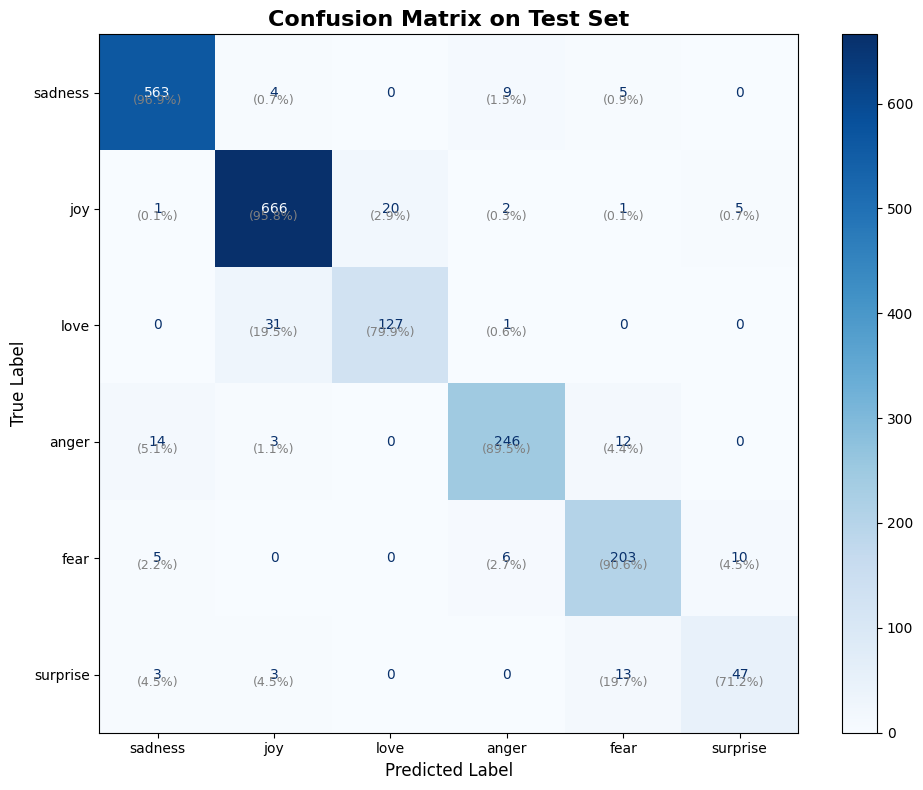

✓ Сохранен файл: artifacts/confusion_matrix.png
  - Размер матрицы: (6, 6)
  - Всего примеров в test: 2000

Точность по каждому классу (из матрицы ошибок):
  sadness   : 96.90% (563/581)
  joy       : 95.83% (666/695)
  love      : 79.87% (127/159)
  anger     : 89.45% (246/275)
  fear      : 90.62% (203/224)
  surprise  : 71.21% (47/66)

4.3. ДОПОЛНИТЕЛЬНЫЕ АРТЕФАКТЫ (опционально)
----------------------------------------


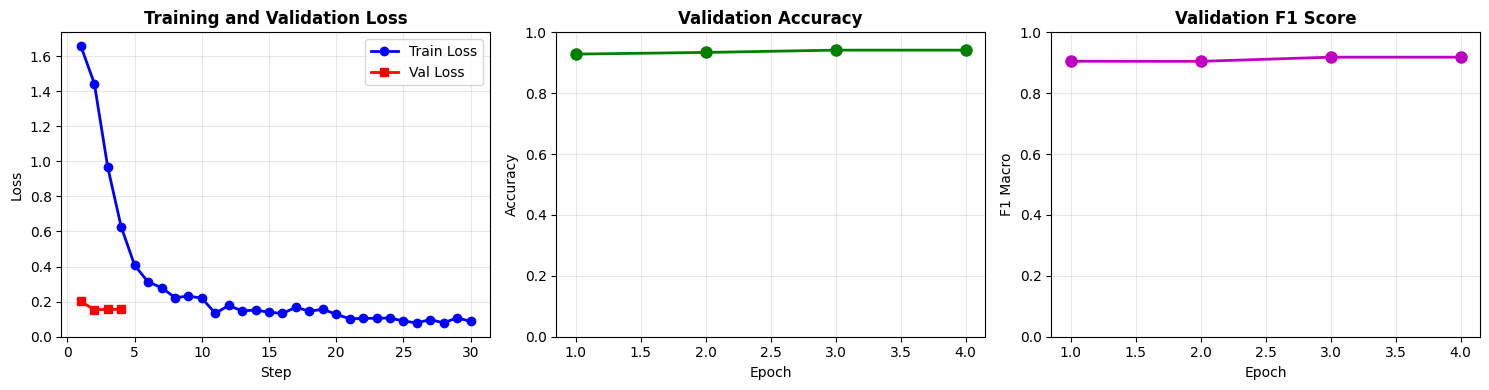

✓ Сохранен файл: artifacts/training_curves.png

Создание tokenization_examples.txt...
✓ Сохранен файл: artifacts/tokenization_examples.txt

4.4. ПРОВЕРКА АРТЕФАКТОВ
----------------------------------------

Содержимое папки 'artifacts/':
  ✓ sample_predictions.csv - 23.38 KB
  ◉ (опционально) training_curves.png - 63.63 KB
  ◉ (опционально) tokenization_examples.txt - 5.52 KB
  ✓ confusion_matrix.png - 101.33 KB

Проверка обязательных артефактов:
  ✓ sample_predictions.csv - найден
  ✓ confusion_matrix.png - найден

✅ Все обязательные артефакты успешно созданы!

4.5. СТАТИСТИКА ПО АРТЕФАКТАМ
----------------------------------------
sample_predictions.csv:
  - Всего записей: 200
  - Уникальных текстов: 200
  - Распределение true_label:
      joy: 62 (31.0%)
      sadness: 61 (30.5%)
      anger: 30 (15.0%)
      fear: 28 (14.0%)
      love: 15 (7.5%)
      surprise: 4 (2.0%)

confusion_matrix.png:
  - Размер изображения: (6, 6)
  - Диагональные элементы (правильные предсказания): 1852
 

In [48]:
print("=" * 80)
print("4. АРТЕФАКТЫ")
print("=" * 80)

import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Создаем папку для артефактов, если её нет
os.makedirs("artifacts", exist_ok=True)
print("\n✓ Папка 'artifacts/' создана/проверена")

# 4.1. sample_predictions.csv
print("\n4.1. СОЗДАНИЕ sample_predictions.csv")
print("-" * 40)

# Берем примеры из test (первые 200 или все, если меньше)
num_samples = min(200, len(dataset["test"]))
sample_texts_all = dataset["test"]["text"][:num_samples]
sample_true_all = dataset["test"]["label"][:num_samples]

# Получаем предсказания для этих примеров
# Используем уже обученную модель
model.eval()
sample_preds_all = []
sample_confidences_all = []

for text in sample_texts_all:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        confidence = torch.max(probs).item()

    sample_preds_all.append(pred)
    sample_confidences_all.append(confidence)

# Создаем DataFrame
predictions_df = pd.DataFrame({
    "text": sample_texts_all,
    "true_label": [emotion_labels[l] for l in sample_true_all],
    "pred_label": [emotion_labels[l] for l in sample_preds_all],
    "confidence": [f"{c:.4f}" for c in sample_confidences_all]
})

# Добавляем колонку "correct" для наглядности
predictions_df["correct"] = predictions_df["true_label"] == predictions_df["pred_label"]

# Сохраняем в CSV
csv_path = "artifacts/sample_predictions.csv"
predictions_df.to_csv(csv_path, index=False)
print(f"✓ Сохранен файл: {csv_path}")
print(f"  - Количество примеров: {len(predictions_df)}")
print(f"  - Правильных предсказаний: {predictions_df['correct'].sum()}")
print(f"  - Точность на выборке: {predictions_df['correct'].sum()/len(predictions_df):.2%}")

# Показываем первые 10 строк
print("\nПервые 10 предсказаний:")
print(predictions_df.head(10).to_string(index=False))

# 4.2. confusion_matrix.png
print("\n4.2. СОЗДАНИЕ confusion_matrix.png")
print("-" * 40)

# Получаем все предсказания для test (если ещё не сделали)
if 'test_preds' not in dir():
    print("Получение предсказаний для всей test выборки...")
    test_predictions_full = trainer.predict(tokenized_test)
    test_preds_full = np.argmax(test_predictions_full.predictions, axis=1)
    test_labels_full = test_predictions_full.label_ids
else:
    test_preds_full = test_preds
    test_labels_full = test_labels

# Создаем матрицу ошибок
cm = confusion_matrix(test_labels_full, test_preds_full)
class_names = ["sadness", "joy", "love", "anger", "fear", "surprise"]

# Визуализируем
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", ax=ax, values_format="d")

# Настраиваем внешний вид
plt.title("Confusion Matrix on Test Set", fontsize=16, fontweight="bold")
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

# Добавляем проценты для наглядности (опционально)
# Нормализуем по строкам для процентов
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if cm[i, j] > 0:
            plt.text(j, i, f"\n({cm_percent[i, j]:.1%})",
                    ha="center", va="center", color="gray", fontsize=9)

plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✓ Сохранен файл: artifacts/confusion_matrix.png")
print(f"  - Размер матрицы: {cm.shape}")
print(f"  - Всего примеров в test: {cm.sum()}")

# Выводим accuracy по каждому классу из матрицы
print("\nТочность по каждому классу (из матрицы ошибок):")
for i, class_name in enumerate(class_names):
    class_correct = cm[i, i]
    class_total = cm[i, :].sum()
    class_accuracy = class_correct / class_total
    print(f"  {class_name:10s}: {class_accuracy:.2%} ({class_correct}/{class_total})")

# 4.3. Дополнительные артефакты (опционально, но приветствуется)
print("\n4.3. ДОПОЛНИТЕЛЬНЫЕ АРТЕФАКТЫ (опционально)")
print("-" * 40)

# 4.3.1. training_curves.png (если ещё не создали)
try:
    # Извлекаем историю обучения
    log_history = trainer.state.log_history

    # Собираем метрики
    steps = []
    train_losses = []
    val_losses = []
    val_accuracies = []
    val_f1s = []

    step_counter = 0
    for log in log_history:
        if 'loss' in log and 'epoch' in log:
            step_counter += 1
            steps.append(step_counter)
            train_losses.append(log['loss'])
        if 'eval_loss' in log:
            val_losses.append(log['eval_loss'])
        if 'eval_accuracy' in log:
            val_accuracies.append(log['eval_accuracy'])
        if 'eval_f1_macro' in log:
            val_f1s.append(log['eval_f1_macro'])

    if len(train_losses) > 0:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        # Loss
        axes[0].plot(range(1, len(train_losses)+1), train_losses, 'b-o', label='Train Loss', linewidth=2, markersize=6)
        if val_losses:
            axes[0].plot(range(1, len(val_losses)+1), val_losses, 'r-s', label='Val Loss', linewidth=2, markersize=6)
        axes[0].set_xlabel('Step', fontsize=10)
        axes[0].set_ylabel('Loss', fontsize=10)
        axes[0].set_title('Training and Validation Loss', fontsize=12, fontweight='bold')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Accuracy
        if val_accuracies:
            axes[1].plot(range(1, len(val_accuracies)+1), val_accuracies, 'g-o', linewidth=2, markersize=8)
            axes[1].set_ylim([0, 1])
        axes[1].set_xlabel('Epoch', fontsize=10)
        axes[1].set_ylabel('Accuracy', fontsize=10)
        axes[1].set_title('Validation Accuracy', fontsize=12, fontweight='bold')
        axes[1].grid(True, alpha=0.3)

        # F1 Score
        if val_f1s:
            axes[2].plot(range(1, len(val_f1s)+1), val_f1s, 'm-o', linewidth=2, markersize=8)
            axes[2].set_ylim([0, 1])
        axes[2].set_xlabel('Epoch', fontsize=10)
        axes[2].set_ylabel('F1 Macro', fontsize=10)
        axes[2].set_title('Validation F1 Score', fontsize=12, fontweight='bold')
        axes[2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig("artifacts/training_curves.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("✓ Сохранен файл: artifacts/training_curves.png")
    else:
        print("! Недостаточно данных для построения кривых обучения")

except Exception as e:
    print(f"! Не удалось создать training_curves.png: {e}")

# 4.3.2. tokenization_examples.txt (примеры токенизации)
print("\nСоздание tokenization_examples.txt...")

token_examples_path = "artifacts/tokenization_examples.txt"
with open(token_examples_path, "w", encoding="utf-8") as f:
    f.write("=" * 80 + "\n")
    f.write("ПРИМЕРЫ ТОКЕНИЗАЦИИ ДЛЯ ДАТАСЕТА EMOTION\n")
    f.write("=" * 80 + "\n\n")

    # Берем несколько примеров из датасета
    example_texts = [
        dataset["train"][0]["text"],
        dataset["train"][100]["text"],
        dataset["train"][500]["text"],
        "I am feeling absolutely wonderful and joyful today!",
        "This is the worst day of my life, I'm so angry."
    ]

    for i, text in enumerate(example_texts, 1):
        f.write(f"\n{'='*60}\n")
        f.write(f"ПРИМЕР {i}:\n")
        f.write(f"Исходный текст: {text}\n\n")

        # Токенизация
        tokens = tokenizer.tokenize(text)
        input_ids = tokenizer.encode(text, add_special_tokens=True)

        f.write(f"Количество токенов: {len(tokens)}\n")
        f.write(f"Токены: {tokens}\n\n")
        f.write(f"input_ids: {input_ids}\n")
        f.write(f"Длина input_ids: {len(input_ids)}\n\n")

        # Показываем special tokens
        encoded = tokenizer(text, add_special_tokens=True)
        tokens_with_special = tokenizer.convert_ids_to_tokens(encoded['input_ids'])
        f.write(f"Токены со специальными токенами: {tokens_with_special}\n")
        f.write(f"[CLS] - начало последовательности\n")
        f.write(f"[SEP] - конец последовательности\n")
        f.write(f"[PAD] - паддинг (если используется)\n")

        # attention_mask
        f.write(f"\nattention_mask: {encoded['attention_mask']}\n")
        f.write("(1 - реальный токен, 0 - паддинг)\n")

        f.write("\n" + "-"*60 + "\n")

print(f"✓ Сохранен файл: {token_examples_path}")

# 4.4. Проверка всех артефактов
print("\n4.4. ПРОВЕРКА АРТЕФАКТОВ")
print("-" * 40)

artifacts_dir = "artifacts"
required_files = ["sample_predictions.csv", "confusion_matrix.png"]
optional_files = ["training_curves.png", "tokenization_examples.txt"]

print(f"\nСодержимое папки '{artifacts_dir}/':")
for file in os.listdir(artifacts_dir):
    file_path = os.path.join(artifacts_dir, file)
    file_size = os.path.getsize(file_path)
    if file_size < 1024:
        size_str = f"{file_size} bytes"
    else:
        size_str = f"{file_size/1024:.2f} KB"

    status = "✓" if file in required_files else "◉ (опционально)"
    print(f"  {status} {file} - {size_str}")

# Проверяем обязательные артефакты
print("\nПроверка обязательных артефактов:")
all_required_exist = True
for required_file in required_files:
    file_path = os.path.join(artifacts_dir, required_file)
    if os.path.exists(file_path):
        print(f"  ✓ {required_file} - найден")
    else:
        print(f"  ✗ {required_file} - ОТСУТСТВУЕТ!")
        all_required_exist = False

if all_required_exist:
    print("\n✅ Все обязательные артефакты успешно созданы!")
else:
    print("\n❌ Некоторые обязательные артефакты отсутствуют. Проверьте ошибки выше.")

# 4.5. Краткая статистика по артефактам
print("\n4.5. СТАТИСТИКА ПО АРТЕФАКТАМ")
print("-" * 40)

print(f"sample_predictions.csv:")
print(f"  - Всего записей: {len(predictions_df)}")
print(f"  - Уникальных текстов: {len(predictions_df['text'].unique())}")
print(f"  - Распределение true_label:")
for label, count in predictions_df['true_label'].value_counts().items():
    print(f"      {label}: {count} ({count/len(predictions_df):.1%})")

print(f"\nconfusion_matrix.png:")
print(f"  - Размер изображения: {cm.shape}")
print(f"  - Диагональные элементы (правильные предсказания): {cm.trace()}")
print(f"  - Вне диагонали (ошибки): {cm.sum() - cm.trace()}")

# 4.6. Примеры ошибок из sample_predictions
print("\n4.6. ПРИМЕРЫ ОШИБОК (из sample_predictions.csv)")
print("-" * 40)

errors_df = predictions_df[predictions_df["correct"] == False]
if len(errors_df) > 0:
    print(f"Всего ошибок в sample_predictions: {len(errors_df)} ({(len(errors_df)/len(predictions_df)):.1%})")
    print("\nТоп-5 примеров ошибок:")
    for i, (idx, row) in enumerate(errors_df.head(5).iterrows()):
        print(f"\n  Ошибка {i+1}:")
        print(f"    Текст: {row['text'][:80]}..." if len(row['text']) > 80 else f"    Текст: {row['text']}")
        print(f"    True: {row['true_label']} → Pred: {row['pred_label']}")
        print(f"    Уверенность: {row['confidence']}")
else:
    print("  Ошибок нет! Модель идеально предсказала все примеры в выборке.")

print("\n" + "=" * 80)
print("ВСЕ АРТЕФАКТЫ УСПЕШНО СОЗДАНЫ!")
print("=" * 80)
print("\nСозданные файлы:")
print("  📁 artifacts/")
print("     ├── 📄 sample_predictions.csv  (обязательный)")
print("     ├── 🖼️  confusion_matrix.png   (обязательный)")
if os.path.exists("artifacts/training_curves.png"):
    print("     ├── 🖼️  training_curves.png    (опциональный)")
if os.path.exists("artifacts/tokenization_examples.txt"):
    print("     └── 📝 tokenization_examples.txt (опциональный)")